# ReLU activation

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import tensorflow as tf
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.activations import linear, relu, sigmoid

import warnings
warnings.simplefilter(action = 'ignore', category = UserWarning)

<a name="2"></a>
## 2 - ReLU Activation
This week, a new activation was introduced, the Rectified Linear Unit (ReLU). 
$$ a = max(0,z) $$

In [4]:
def plt_act_trio(): 
    X = np.linspace(-5, 5, 100)
    fig, ax = plt.subplots(1, 3, figsize=(6, 2))
    ax[0].plot(X,tf.keras.activations.linear(X))
    ax[0].axvline(0, lw=0.3, c="black")
    ax[0].axhline(0, lw=0.3, c="black")
    ax[0].set_title("Linear")
    ax[1].plot(X,tf.keras.activations.sigmoid(X))
    ax[1].axvline(0, lw=0.3, c="black")
    ax[1].axhline(0, lw=0.3, c="black")
    ax[1].set_title("Sigmoid")
    ax[2].plot(X,tf.keras.activations.relu(X))
    ax[2].axhline(0, lw=0.3, c="black")
    ax[2].axvline(0, lw=0.3, c="black")
    ax[2].set_title("ReLu")
    fig.suptitle("Common Activation Functions", fontsize=14)
    fig.tight_layout(pad=0.2)
    plt.show()

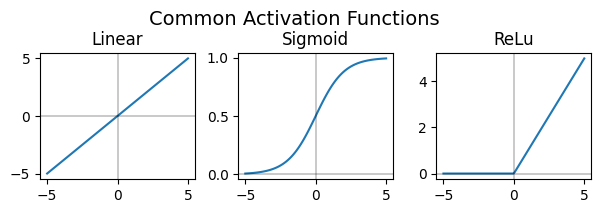

In [5]:
plt_act_trio()

## 2 - ReLU Activation 

The example from the lecture on the right shows an application of the ReLU. In this example, the derived "awareness" feature is not binary but has a continuous range of values. The sigmoid is best for on/off or binary situation. The ReLU provides a continuous linear relationshipo. Additionally it has an "of" range where the output is zero. The "off" feature makes the ReLU a Non-Linear activation

The exercise will use the network below in a regression problem where you must model a piecewise linear target :
<img align="center" src="./images/C2_W2_ReLU_Network.png"     style=" width:650px; padding: 10px 20px; ">

The network has 3 units in the first layer. Each is required to from the target. Unit 0 is pre-programmed and fixed to map the first segment. You will modify weights and biases in unit 1 and 2 to model the 2nd and 3rd segment. The output is also fixed and simply sums of the outputs of the first layer. 

<img align="right" src="./images/C2_W2_ReLU_Plot.png">

Starting at the top, unit 0 is responsible for the first segmenet mark with a 1. Both a linear function $z$ and function following the ReLU $a$ are shown. You an see that the ReLU cuts off the function after the interval [0, 1].  This is important as it prevents Unit 0 from interfering with the following segmenet. 

Unit 1 is responsible for the 2nd segment. Here the ReLU kept this unit quiet until after x is 1. Since the first unit is not contributing. The slope for unit 1, $w_1^{[1]}$ is just the slope of the target line. The bias must be adjusted to keep the output negative until x has reached 1. Not how the contribution of Unit 1 extends to the 3rd segment as well. 

Unit 2 is responsible for the 3rd segment. The ReLU again zeros the output until x reaches the right value. The slope of the unit, $w_2{[1]}$ must be set so that the sum of unit 1 and 2 have the desired slope. The bias is again adjusted to keep the output negative until x has reached 2. 